# Suction Prediction Model Development Process

## 1. Data Understanding & Exploration

### Dataset Overview
- **Target Variable**: Suction (continuous variable ranging from 30 to 1500)
- **Features**: 9 input variables
  - `pd` - Dry density
  - `w` - Water content (%)
  - `pb` - Bulk density  
  - `P.I` - Plasticity Index
  - `O` - Optimum moisture content
  - `k` - Permeability coefficient
  - `n` - Porosity
  - `D60` - Particle size parameter
  - `Ya` - Apparent cohesion

### Data Exploration Steps
1. **Statistical Summary**: Mean, median, std deviation, min/max for each variable
2. **Data Quality Check**: Missing values, outliers, data types
3. **Distribution Analysis**: Histograms and box plots for each variable
4. **Correlation Analysis**: Relationships between features and target variable
5. **Feature Engineering**: Create new features if needed (ratios, interactions)

## 2. Data Preprocessing

### Data Cleaning
- Handle missing values (if any)
- Remove or treat outliers
- Ensure consistent data types
- Handle scientific notation in permeability coefficient (k)

### Feature Scaling
- **Standardization**: Z-score normalization for features with different scales
- **Normalization**: Min-max scaling if needed
- Essential due to wide range of values (e.g., k values in scientific notation)

### Data Splitting
- **Training Set**: 70-80% of data for model training
- **Validation Set**: 10-15% for hyperparameter tuning
- **Test Set**: 10-15% for final model evaluation

## 3. Model Selection Strategy

### Recommended Models (in order of priority)

#### 1. **Random Forest Regression** (Primary Choice)
- **Why**: Handles non-linear relationships, feature interactions, robust to outliers
- **Pros**: Good interpretability, handles mixed data types, less overfitting
- **Hyperparameters**: n_estimators, max_depth, min_samples_split

#### 2. **Gradient Boosting (XGBoost/LightGBM)** (Secondary Choice)
- **Why**: Often achieves best performance on tabular data
- **Pros**: Excellent predictive power, handles complex patterns
- **Hyperparameters**: learning_rate, n_estimators, max_depth, regularization

#### 3. **Support Vector Regression (SVR)** (Alternative)
- **Why**: Good for non-linear relationships with kernel trick
- **Pros**: Effective in high-dimensional spaces
- **Hyperparameters**: C, epsilon, kernel type (RBF, polynomial)

#### 4. **Neural Network (MLP)** (For comparison)
- **Why**: Can capture complex non-linear patterns
- **Architecture**: 2-3 hidden layers with dropout for regularization

#### 5. **Linear Models** (Baseline)
- **Multiple Linear Regression**: Simple baseline
- **Ridge/Lasso Regression**: With regularization for feature selection

## 4. Feature Engineering & Selection

### Feature Engineering
1. **Polynomial Features**: Create interaction terms (pd × w, pb × P.I)
2. **Ratio Features**: Create meaningful ratios (w/O, pb/pd)
3. **Log Transformation**: For skewed variables like permeability (k)
4. **Binning**: Categorical versions of continuous variables if needed

### Feature Selection Methods
1. **Correlation Analysis**: Remove highly correlated features (>0.9)
2. **Univariate Selection**: Statistical tests (f_regression)
3. **Recursive Feature Elimination**: With cross-validation
4. **Feature Importance**: From tree-based models
5. **L1 Regularization**: Automatic feature selection

## 5. Model Training & Validation

### Training Strategy
1. **Cross-Validation**: 5-fold or 10-fold CV for robust evaluation
2. **Hyperparameter Tuning**: Grid search or random search
3. **Early Stopping**: For gradient boosting and neural networks
4. **Ensemble Methods**: Combine multiple models for better performance

### Evaluation Metrics
- **RMSE** (Root Mean Square Error): Primary metric for continuous prediction
- **MAE** (Mean Absolute Error): Robust to outliers
- **R²** (R-squared): Explained variance
- **MAPE** (Mean Absolute Percentage Error): Relative error

## 6. Model Interpretation & Analysis

### Feature Importance
- **Permutation Importance**: Model-agnostic method
- **SHAP Values**: Detailed feature contribution analysis
- **Partial Dependence Plots**: Understand feature-target relationships

### Model Diagnostics
- **Residual Analysis**: Check for patterns in errors
- **Learning Curves**: Assess overfitting/underfitting
- **Prediction vs Actual Plots**: Visual assessment of model performance

## 7. Model Deployment Considerations

### Model Validation
- **Out-of-sample Testing**: Final evaluation on unseen test set
- **Cross-validation Stability**: Consistent performance across folds
- **Business Logic Validation**: Ensure predictions make physical sense

### Production Readiness
- **Model Serialization**: Save trained model (pickle, joblib)
- **Input Validation**: Ensure input data quality
- **Monitoring**: Track model performance over time
- **Retraining Strategy**: When and how to update the model

## 8. Implementation Steps

### Phase 1: Data Analysis
```python
1. Load and explore the dataset
2. Statistical summary and visualization
3. Correlation analysis
4. Outlier detection and treatment
```

### Phase 2: Preprocessing
```python
1. Feature scaling and transformation
2. Train-test split
3. Feature engineering
```

### Phase 3: Model Development
```python
1. Train baseline linear model
2. Train Random Forest with hyperparameter tuning
3. Train Gradient Boosting model
4. Compare models using cross-validation
```

### Phase 4: Model Selection & Optimization
```python
1. Select best performing model
2. Feature importance analysis
3. Final model training on full training set
4. Evaluation on test set
```

## 9. Expected Challenges & Solutions

### Challenges
- **Small Dataset Size**: ~49 samples may limit model complexity
- **Feature Scale Differences**: Wide range of feature magnitudes
- **Non-linear Relationships**: Suction may have complex dependencies
- **Overfitting Risk**: Small dataset with 9 features

### Solutions
- **Regularization**: Use Ridge/Lasso or tree-based models with constraints
- **Cross-validation**: Robust evaluation with limited data
- **Feature Selection**: Reduce dimensionality to prevent overfitting
- **Ensemble Methods**: Combine multiple models for stability

## 10. Success Criteria

### Model Performance Targets
- **R² > 0.8**: Good explanatory power
- **RMSE < 20% of target range**: Acceptable prediction accuracy
- **Stable CV Performance**: Low variance across folds
- **Interpretable Results**: Clear feature importance and relationships

This systematic approach ensures we build a robust, interpretable, and well-validated model for suction prediction.

# Why?

## Key Features of the Solution:

- Complete ML Pipeline: From data loading to model deployment
- Multiple Model Comparison: Tests 5 different algorithms to find the best performer
- Proper Data Preprocessing: Handles outliers, scaling, and feature engineering
- Feature Engineering: Creates meaningful new features from existing ones
- Model Validation: Uses cross-validation for robust evaluation
- Feature Importance: Analyzes which variables are most predictive

## Why This Approach is Better:

- Systematic Process: Follows the outline we discussed earlier
- Scientific Rigor: Proper train/test splits, cross-validation, multiple metrics
- Practical Focus: Ready-to-use Python code for actual model development
- Model Interpretability: Understanding which features matter most
- Production Ready: Includes prediction function for new data

## Models Tested:

- Linear Regression (baseline)
- Ridge Regression (regularized linear)
- Lasso Regression (feature selection)
- Random Forest (ensemble method)
- Support Vector Regression (non-linear)



In [17]:
# Import dependencies

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression
import warnings
import joblib

In [9]:
# Load and explore the dataset
def load_and_explore_data():
    # Load the CSV data
    #df = pd.read_csv('abdullahi_karaye_new_dataset.csv')
    df = pd.read_csv('augmented_dataset_interpolation.csv')


    print("=== DATASET OVERVIEW ===")
    print(f"Dataset shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")
    print("\nFirst 5 rows:")
    print(df.head())

    print("\n=== DATA TYPES ===")
    print(df.dtypes)

    print("\n=== MISSING VALUES ===")
    print(df.isnull().sum())

    print("\n=== STATISTICAL SUMMARY ===")
    print(df.describe())

    return df

In [10]:
def preprocess_data(df):
    print("\n=== DATA PREPROCESSING ===")

    # Check for outliers using IQR method
    print("Checking for outliers...")
    outliers_info = {}

    for column in df.columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)][column]
        outliers_info[column] = len(outliers)

    print("Outliers per column:")
    for col, count in outliers_info.items():
        print(f"{col}: {count} outliers")

    # Handle scientific notation in 'k' column
    df['k'] = df['k'].astype(float)

    # Create log transformation for highly skewed 'k' values
    df['log_k'] = np.log10(df['k'].abs() + 1e-15)  # Add small constant to avoid log(0)

    print(f"\nProcessed dataset shape: {df.shape}")
    return df

# Exploratory Data Analysis

In [11]:
# Exploratory Data Analysis
def exploratory_analysis(df):
    print("\n=== EXPLORATORY DATA ANALYSIS ===")

    # Correlation analysis
    features = ['pd', 'w', 'pb', 'P.I', 'O', 'k', 'n', 'D60', 'Ya']
    correlation_with_target = []

    for feature in features:
        corr = df[feature].corr(df['Suction'])
        correlation_with_target.append({
            'Feature': feature,
            'Correlation': corr,
            'Abs_Correlation': abs(corr)
        })

    corr_df = pd.DataFrame(correlation_with_target)
    corr_df = corr_df.sort_values('Abs_Correlation', ascending=False)

    print("Feature correlation with Suction (sorted by absolute value):")
    print(corr_df)

    # Feature importance ranking
    top_features = corr_df.head(6)['Feature'].tolist()
    print(f"\nTop 6 features by correlation: {top_features}")

    return corr_df, top_features

# Feature engineering

In [12]:
def feature_engineering(df):
    print("\n=== FEATURE ENGINEERING ===")

    # Create interaction features
    df['pd_w_ratio'] = df['pd'] / (df['w'] + 1e-6)  # Avoid division by zero
    df['pb_pd_ratio'] = df['pb'] / df['pd']
    df['w_O_ratio'] = df['w'] / (df['O'] + 1e-6)

    # Polynomial features for top correlated variables
    df['pd_squared'] = df['pd'] ** 2
    df['w_squared'] = df['w'] ** 2

    # Create categorical features based on ranges
    df['moisture_level'] = pd.cut(df['w'], bins=3, labels=['Low', 'Medium', 'High'])
    df['density_level'] = pd.cut(df['pd'], bins=3, labels=['Low', 'Medium', 'High'])

    # Convert categorical to numeric
    df['moisture_level_num'] = df['moisture_level'].cat.codes
    df['density_level_num'] = df['density_level'].cat.codes

    print("New engineered features created:")
    new_features = ['pd_w_ratio', 'pb_pd_ratio', 'w_O_ratio', 'pd_squared', 'w_squared',
                   'moisture_level_num', 'density_level_num', 'log_k']
    print(new_features)

    return df, new_features


# Model training and evaluation

In [15]:
# Hyperparameter grids for Decision Tree and XGBoost
param_grid_dt = {
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0]
}

In [18]:
def train_models(df, top_features, engineered_features):
    print("\n=== MODEL TRAINING ===")

    # Prepare features and target
    all_features = top_features + engineered_features
    X = df[all_features].fillna(df[all_features].mean())  # Handle any NaN values
    y = df['Suction']

    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Scale the features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Initialize models
    models = {
        'Linear Regression': LinearRegression(),
        'Ridge Regression': Ridge(alpha=1.0),
        'Lasso Regression': Lasso(alpha=1.0),
        'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
        'SVR': SVR(kernel='rbf', C=1.0, gamma='scale'),
        'Decision Tree': DecisionTreeRegressor(random_state=42),
        'XGBoost': XGBRegressor(random_state=42)
    }

    # Hyperparameter grids for Decision Tree and XGBoost
    param_grid_dt = {
        'max_depth': [3, 5, 7, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }

    param_grid_xgb = {
        'n_estimators': [50, 100, 200],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.3],
        'subsample': [0.8, 1.0]
    }

    # Store results
    results = {}

    # Train and evaluate models
    for name, model in models.items():
        print(f"\nTraining {name}...")

        # Use scaled data for linear models and SVR
        if name in ['Linear Regression', 'Ridge Regression', 'Lasso Regression', 'SVR']:
            X_train_model = X_train_scaled
            X_test_model = X_test_scaled
        else:
            X_train_model = X_train
            X_test_model = X_test

        # Perform GridSearchCV for Decision Tree and XGBoost
        if name == 'Decision Tree':
            grid_search = GridSearchCV(
                model, param_grid_dt, cv=5, scoring='neg_mean_squared_error', n_jobs=-1
            )
            grid_search.fit(X_train_model, y_train)
            best_model = grid_search.best_estimator_
            print(f"Best parameters for {name}: {grid_search.best_params_}")
        elif name == 'XGBoost':
            grid_search = GridSearchCV(
                model, param_grid_xgb, cv=5, scoring='neg_mean_squared_error', n_jobs=-1
            )
            grid_search.fit(X_train_model, y_train)
            best_model = grid_search.best_estimator_
            print(f"Best parameters for {name}: {grid_search.best_params_}")
        else:
            best_model = model
            best_model.fit(X_train_model, y_train)

        # Make predictions
        y_pred_train = best_model.predict(X_train_model)
        y_pred_test = best_model.predict(X_test_model)

        # Calculate metrics
        train_r2 = r2_score(y_train, y_pred_train)
        test_r2 = r2_score(y_test, y_pred_test)
        test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
        test_mae = mean_absolute_error(y_test, y_pred_test)

        # Cross-validation
        cv_scores = cross_val_score(
            best_model,
            X_train_model,
            y_train,
            cv=5,
            scoring='r2'
        )

        results[name] = {
            'Train R2': train_r2,
            'Test R2': test_r2,
            'Test RMSE': test_rmse,
            'Test MAE': test_mae,
            'CV Mean R2': cv_scores.mean(),
            'CV Std R2': cv_scores.std(),
            'Model': best_model,
            'Predictions': y_pred_test
        }
        print(f"{name} trained and evaluated.")
        print(f"Saving Model {name}")
        joblib.dump(best_model, f"{name}.pkl")  # Save the model
        print(f"Model {name} saved.")

        # Feature importance for tree-based models
        if name in ['Random Forest', 'Decision Tree', 'XGBoost']:
            print(f"\nFeature Importance for {name}:")
            importance = best_model.feature_importances_
            for feat, imp in zip(all_features, importance):
                print(f"{feat}: {imp:.4f}")

    return results, X_test, y_test, scaler, all_features

In [19]:
# Model comparison and selection
def compare_models(results):
    print("\n=== MODEL COMPARISON ===")

    comparison_df = pd.DataFrame({
        'Model': list(results.keys()),
        'Train R2': [results[model]['Train R2'] for model in results.keys()],
        'Test R2': [results[model]['Test R2'] for model in results.keys()],
        'Test RMSE': [results[model]['Test RMSE'] for model in results.keys()],
        'Test MAE': [results[model]['Test MAE'] for model in results.keys()],
        'CV Mean R2': [results[model]['CV Mean R2'] for model in results.keys()],
        'CV Std R2': [results[model]['CV Std R2'] for model in results.keys()]
    })

    print(comparison_df.round(4))

    # Select best model based on CV performance and generalization
    best_model_name = comparison_df.loc[comparison_df['CV Mean R2'].idxmax(), 'Model']
    best_model = results[best_model_name]

    print(f"\nBest Model: {best_model_name}")
    print(f"Best Model CV R2: {best_model['CV Mean R2']:.4f} ± {best_model['CV Std R2']:.4f}")
    print(f"Best Model Test R2: {best_model['Test R2']:.4f}")
    print(f"Best Model Test RMSE: {best_model['Test RMSE']:.4f}")

    return best_model_name, best_model, comparison_df


# Feature importance analysis

In [31]:
def analyze_feature_importance(best_model_name, best_model, feature_names):
    print(f"\n=== FEATURE IMPORTANCE ANALYSIS ({best_model_name}) ===")

    if best_model_name in ['Random Forest', 'Decision Tree', 'XGBoost']:
        importances = best_model['Model'].feature_importances_
        feature_importance_df = pd.DataFrame({
            'Feature': feature_names,
            'Importance': importances
        }).sort_values('Importance', ascending=False)

        print(f"Feature Importance ({best_model_name}):")
        print(feature_importance_df)

    elif best_model_name in ['Ridge Regression', 'Lasso Regression']:
        coefficients = best_model['Model'].coef_
        feature_importance_df = pd.DataFrame({
            'Feature': feature_names,
            'Coefficient': coefficients,
            'Abs_Coefficient': np.abs(coefficients)
        }).sort_values('Abs_Coefficient', ascending=False)

        print(f"Feature Coefficients ({best_model_name}):")
        print(feature_importance_df)

    else:
        print(f"Feature importance not available for {best_model_name}.")
        feature_importance_df = pd.DataFrame({
            'Feature': feature_names,
            'Importance': [0] * len(feature_names)
        })

    return feature_importance_df

In [21]:
# Feature engineering function (reusable)
def engineer_features(input_data):
    """
    Generate engineered features from original features

    Parameters:
    - input_data: dictionary with original features

    Returns:
    - dictionary with all features (original + engineered)
    """
    # Copy original features
    features = input_data.copy()

    # Create interaction features
    features['pd_w_ratio'] = features['pd'] / (features['w'] + 1e-6)  # Avoid division by zero
    features['pb_pd_ratio'] = features['pb'] / features['pd']
    features['w_O_ratio'] = features['w'] / (features['O'] + 1e-6)

    # Polynomial features for top correlated variables
    features['pd_squared'] = features['pd'] ** 2
    features['w_squared'] = features['w'] ** 2

    # Log transformation for permeability
    features['log_k'] = np.log10(features['k'] + 1e-15)  # Add small constant to avoid log(0)

    # Create categorical features based on typical ranges (from training data analysis)
    # These thresholds should be saved from training phase
    if features['w'] <= 14.5:
        features['moisture_level_num'] = 0  # Low
    elif features['w'] <= 18.5:
        features['moisture_level_num'] = 1  # Medium
    else:
        features['moisture_level_num'] = 2  # High

    if features['pd'] <= 1.60:
        features['density_level_num'] = 0  # Low
    elif features['pd'] <= 1.70:
        features['density_level_num'] = 1  # Medium
    else:
        features['density_level_num'] = 2  # High

    return features

In [22]:
def make_prediction(model, scaler, feature_names, original_input):
    """
    Make a prediction for new input values using only original features

    Parameters:
    - model: trained model
    - scaler: fitted scaler (None if not needed)
    - feature_names: list of all feature names (original + engineered)
    - original_input: dictionary with ONLY original features
                     Expected keys: ['pd', 'w', 'pb', 'P.I', 'O', 'k', 'n', 'D60', 'Ya']

    Returns:
    - predicted suction value
    """
    # Validate input
    required_features = ['pd', 'w', 'pb', 'P.I', 'O', 'k', 'n', 'D60', 'Ya']
    missing_features = [f for f in required_features if f not in original_input]
    if missing_features:
        raise ValueError(f"Missing required features: {missing_features}")

    # Generate all features (original + engineered)
    all_features = engineer_features(original_input)

    # Create input array in the correct order
    input_array = np.array([all_features[feature] for feature in feature_names]).reshape(1, -1)

    # Scale if needed (for linear models and SVR)
    if scaler is not None:
        if hasattr(model, 'kernel') or hasattr(model, 'coef_'):  # SVR or Linear models
            input_array = scaler.transform(input_array)

    # Make prediction
    prediction = model.predict(input_array)[0]

    return prediction


# Main execution work


In [23]:
print("SUCTION PREDICTION MODEL DEVELOPMENT")
print("=" * 50)


SUCTION PREDICTION MODEL DEVELOPMENT


In [24]:
# Step 1: Load and explore data
df = load_and_explore_data()

=== DATASET OVERVIEW ===
Dataset shape: (2550, 10)
Columns: ['pd', 'w', 'pb', 'P.I', 'O', 'k', 'n', 'D60', 'Ya', 'Suction']

First 5 rows:
     pd     w      pb   P.I      O             k      n   D60    Ya  Suction
0  1.58  16.5  27.650  24.0  0.313  3.410000e-09  0.395  0.13  26.0    100.0
1  1.67  14.0  25.050  24.0  0.225  1.320000e-09  0.360  0.13  27.0   1500.0
2  1.74  13.7  25.578  24.0  0.252  8.094000e-10  0.333  0.13  70.0    500.0
3  1.84  10.9  21.896  24.0  0.233  1.096000e-10  0.295  0.13  30.0   1000.0
4  1.58  17.0  28.440  20.5  0.329  3.570000e-09  0.375  0.07  27.0    100.0

=== DATA TYPES ===
pd         float64
w          float64
pb         float64
P.I        float64
O          float64
k          float64
n          float64
D60        float64
Ya         float64
Suction    float64
dtype: object

=== MISSING VALUES ===
pd         0
w          0
pb         0
P.I        0
O          0
k          0
n          0
D60        0
Ya         0
Suction    0
dtype: int64

=== STA

In [25]:
# Step 2: Preprocess data
df = preprocess_data(df)


=== DATA PREPROCESSING ===
Checking for outliers...
Outliers per column:
pd: 0 outliers
w: 5 outliers
pb: 10 outliers
P.I: 0 outliers
O: 0 outliers
k: 331 outliers
n: 0 outliers
D60: 0 outliers
Ya: 113 outliers
Suction: 0 outliers

Processed dataset shape: (2550, 11)


In [26]:
# Step 3: Exploratory analysis
corr_df, top_features = exploratory_analysis(df)


=== EXPLORATORY DATA ANALYSIS ===
Feature correlation with Suction (sorted by absolute value):
  Feature  Correlation  Abs_Correlation
4       O    -0.523024         0.523024
8      Ya     0.287645         0.287645
5       k    -0.157577         0.157577
2      pb     0.110311         0.110311
7     D60     0.093778         0.093778
1       w     0.083688         0.083688
6       n     0.064173         0.064173
0      pd    -0.008942         0.008942
3     P.I     0.004751         0.004751

Top 6 features by correlation: ['O', 'Ya', 'k', 'pb', 'D60', 'w']


In [27]:
# Step 4: Feature engineering
df, engineered_features = feature_engineering(df)


=== FEATURE ENGINEERING ===
New engineered features created:
['pd_w_ratio', 'pb_pd_ratio', 'w_O_ratio', 'pd_squared', 'w_squared', 'moisture_level_num', 'density_level_num', 'log_k']


In [28]:
# Step 5: Train models
results, X_test, y_test, scaler, all_features = train_models(df, top_features, engineered_features)



=== MODEL TRAINING ===

Training Linear Regression...
Linear Regression trained and evaluated.
Saving Model Linear Regression
Model Linear Regression saved.

Training Ridge Regression...
Ridge Regression trained and evaluated.
Saving Model Ridge Regression
Model Ridge Regression saved.

Training Lasso Regression...
Lasso Regression trained and evaluated.
Saving Model Lasso Regression
Model Lasso Regression saved.

Training Random Forest...
Random Forest trained and evaluated.
Saving Model Random Forest
Model Random Forest saved.

Feature Importance for Random Forest:
O: 0.2130
Ya: 0.1199
k: 0.0257
pb: 0.0224
D60: 0.0532
w: 0.0058
pd_w_ratio: 0.0125
pb_pd_ratio: 0.0075
w_O_ratio: 0.4026
pd_squared: 0.1015
w_squared: 0.0060
moisture_level_num: 0.0005
density_level_num: 0.0010
log_k: 0.0284

Training SVR...
SVR trained and evaluated.
Saving Model SVR
Model SVR saved.

Training Decision Tree...
Best parameters for Decision Tree: {'max_depth': 7, 'min_samples_leaf': 4, 'min_samples_split':

In [29]:
# Step 6: Model comparison and selection
best_model_name, best_model, comparison_df = compare_models(results)


=== MODEL COMPARISON ===
               Model  Train R2  Test R2  Test RMSE  Test MAE  CV Mean R2  \
0  Linear Regression    0.6688   0.6202   239.1857  185.1373      0.6636   
1   Ridge Regression    0.6643   0.6244   237.8778  184.8021      0.6592   
2   Lasso Regression    0.6590   0.6254   237.5597  184.7460      0.6552   
3      Random Forest    0.9829   0.8646   142.8048   97.2090      0.8611   
4                SVR    0.1763   0.1987   347.4466  271.1247      0.1366   
5      Decision Tree    0.8607   0.7456   195.7673  140.3552      0.7610   
6            XGBoost    0.9985   0.8618   144.3092   96.7948      0.8712   

   CV Std R2  
0     0.0161  
1     0.0183  
2     0.0191  
3     0.0098  
4     0.0154  
5     0.0185  
6     0.0124  

Best Model: XGBoost
Best Model CV R2: 0.8712 ± 0.0124
Best Model Test R2: 0.8618
Best Model Test RMSE: 144.3092


In [32]:
# Step 7: Feature importance analysis
feature_importance_df = analyze_feature_importance(best_model_name, best_model, all_features)



=== FEATURE IMPORTANCE ANALYSIS (XGBoost) ===
Feature Importance (XGBoost):
               Feature  Importance
8            w_O_ratio    0.423051
9           pd_squared    0.122120
0                    O    0.096350
12   density_level_num    0.089620
1                   Ya    0.068466
4                  D60    0.054653
2                    k    0.044110
3                   pb    0.035157
5                    w    0.026056
7          pb_pd_ratio    0.022000
6           pd_w_ratio    0.018416
10           w_squared    0.000000
11  moisture_level_num    0.000000
13               log_k    0.000000


In [33]:
print("\n=== MODEL DEVELOPMENT COMPLETE ===")
print(f"Best performing model: {best_model_name}")
print(f"Model ready for deployment and predictions!")


=== MODEL DEVELOPMENT COMPLETE ===
Best performing model: XGBoost
Model ready for deployment and predictions!


In [34]:
# Example prediction
print("\n=== EXAMPLE PREDICTION ===")
example_input = {
    'pd': 1.60,
    'w': 18.0,
    'pb': 30.0,
    'P.I': 20.0,
    'O': 0.30,
    'k': 1e-10,
    'n': 0.35,
    'D60': 0.10,
    'Ya': 40,

}


=== EXAMPLE PREDICTION ===


In [35]:
print(f"all_features: {all_features}")
print(f"required_features: {top_features}")


all_features: ['O', 'Ya', 'k', 'pb', 'D60', 'w', 'pd_w_ratio', 'pb_pd_ratio', 'w_O_ratio', 'pd_squared', 'w_squared', 'moisture_level_num', 'density_level_num', 'log_k']
required_features: ['O', 'Ya', 'k', 'pb', 'D60', 'w']


In [36]:
feature_names = all_features # Use all_features instead of top_features
user_input = example_input
model = best_model['Model']
suction_prediction = make_prediction(model, scaler, feature_names, user_input)
print(f"Predicted Suction: {suction_prediction:.2f}")

Predicted Suction: 408.84


In [37]:
# The make_prediction function already handles scaling based on the model type.
# We can simplify this block to just call make_prediction regardless of the model type.

prediction = make_prediction(best_model['Model'], scaler, all_features, example_input)

print(f"Predicted Suction: {prediction:.2f}")

Predicted Suction: 408.84


# Production Usage approaches

Don't edit below this point !!!


In [ ]:
# Feature engineering function (reusable)
def engineer_features(input_data):
    """
    Generate engineered features from original features

    Parameters:
    - input_data: dictionary with original features

    Returns:
    - dictionary with all features (original + engineered)
    """
    # Copy original features
    features = input_data.copy()

    # Create interaction features
    features['pd_w_ratio'] = features['pd'] / (features['w'] + 1e-6)  # Avoid division by zero
    features['pb_pd_ratio'] = features['pb'] / features['pd']
    features['w_O_ratio'] = features['w'] / (features['O'] + 1e-6)

    # Polynomial features for top correlated variables
    features['pd_squared'] = features['pd'] ** 2
    features['w_squared'] = features['w'] ** 2

    # Log transformation for permeability
    features['log_k'] = np.log10(features['k'] + 1e-15)  # Add small constant to avoid log(0)

    # Create categorical features based on typical ranges (from training data analysis)
    # These thresholds should be saved from training phase
    if features['w'] <= 14.5:
        features['moisture_level_num'] = 0  # Low
    elif features['w'] <= 18.5:
        features['moisture_level_num'] = 1  # Medium
    else:
        features['moisture_level_num'] = 2  # High

    if features['pd'] <= 1.60:
        features['density_level_num'] = 0  # Low
    elif features['pd'] <= 1.70:
        features['density_level_num'] = 1  # Medium
    else:
        features['density_level_num'] = 2  # High

    return features

In [ ]:
# Updated prediction class for production use
class SuctionPredictor:
    """
    Production-ready suction prediction class
    """
    def __init__(self, model, scaler, feature_names, model_name):
        self.model = model
        self.scaler = scaler
        self.feature_names = feature_names
        self.model_name = model_name
        self.required_features = ['pd', 'w', 'pb', 'P.I', 'O', 'k', 'n', 'D60', 'Ya']

    def predict(self, input_data):
        """
        Predict suction from original features only

        Parameters:
        - input_data: dict with keys ['pd', 'w', 'pb', 'P.I', 'O', 'k', 'n', 'D60', 'Ya']

        Returns:
        - predicted suction value
        """
        return make_prediction(self.model, self.scaler, self.feature_names, input_data)

    def predict_batch(self, input_list):
        """
        Predict suction for multiple inputs

        Parameters:
        - input_list: list of dictionaries, each with original features

        Returns:
        - list of predictions
        """
        return [self.predict(input_data) for input_data in input_list]

    def get_feature_info(self):
        """
        Return information about required input features
        """
        feature_info = {
            'pd': 'Dry density (g/cm³)',
            'w': 'Water content (%)',
            'pb': 'Bulk density (g/cm³)',
            'P.I': 'Plasticity Index',
            'O': 'Optimum moisture content',
            'k': 'Permeability coefficient (m/s)',
            'n': 'Porosity',
            'D60': 'Particle size parameter (mm)',
            'Ya': 'Apparent cohesion (kPa)'
        }
        return feature_info

In [ ]:
# Step 7: Feature importance analysis
feature_importance_df = analyze_feature_importance(best_model_name, best_model, all_features)


=== FEATURE IMPORTANCE ANALYSIS (Random Forest) ===
Feature Importance (Random Forest):
               Feature  Importance
8            w_O_ratio    0.482455
0                    O    0.251486
1                   Ya    0.080885
9           pd_squared    0.034792
10           w_squared    0.029534
3                   pb    0.028798
6           pd_w_ratio    0.021227
4                    w    0.020625
7          pb_pd_ratio    0.019062
5                  D60    0.011693
13               log_k    0.011571
2                    k    0.006504
12   density_level_num    0.001019
11  moisture_level_num    0.000350


# Data augmentation techniques

In [ ]:
from imblearn.over_sampling import SMOTE
import pandas as pd

# 1. Synthetic Data Generation with SMOTE (Synthetic Minority Oversampling Technique)
SMOTE is commonly used for imbalanced datasets but can also generate synthetic samples for small datasets.
It creates new data points by interpolating between existing ones.

Notes:
- SMOTE assumes the data is continuous, which fits your numerical dataset.
- You can adjust k_neighbors (e.g., 3 or 5) based on dataset size and feature complexity.
- This could generate, for example, 500–1000 new samples.

In [ ]:
data = pd.read_csv('abdullahi_karaye_new_dataset.csv')

In [ ]:
data.head()

,pd,w,pb,P.I,O,k,n,D60,Ya,Suction
0,1.58,16.5,27.650,24.0,0.313,3.410000e-09,0.395,0.13,26,100
1,1.67,14.0,25.050,24.0,0.225,1.320000e-09,0.360,0.13,27,1500
2,1.74,13.7,25.578,24.0,0.252,8.094000e-10,0.333,0.13,70,500
3,1.84,10.9,21.896,24.0,0.233,1.096000e-10,0.295,0.13,30,1000
4,1.58,17.0,28.440,20.5,0.329,3.570000e-09,0.375,0.07,27,100


In [ ]:
# Separate features and target
X = data.drop('Suction', axis=1)
y = data['Suction']


In [ ]:

# Initialize SMOTE
# smote = SMOTE(sampling_strategy='auto', random_state=42, k_neighbors=5)
# Check class distribution
print(y.value_counts())

# Initialize SMOTE with a smaller n_neighbors
smote = SMOTE(sampling_strategy='auto', random_state=42, k_neighbors=1)

Suction
100     17
500     15
1000    10
1500     7
30       1
Name: count, dtype: int64


In [ ]:
# Generate synthetic samples
X_synthetic, y_synthetic = smote.fit_resample(X, y)

ValueError: Expected n_neighbors <= n_samples_fit, but n_neighbors = 2, n_samples_fit = 1, n_samples = 1

In [ ]:

# Combine synthetic features and target into a new DataFrame
synthetic_data = pd.DataFrame(X_synthetic, columns=X.columns)
synthetic_data['Suction'] = y_synthetic

# Save the augmented dataset
synthetic_data.to_csv('augmented_dataset_smote.csv', index=False)

# 2. Bootstrapping (Resampling with Replacement)
Bootstrapping involves randomly sampling the dataset with replacement to create new datasets of the desired size.

Steps:
- Randomly sample rows from the dataset with replacement.
- Repeat until the desired dataset size is reached (e.g., 500 or 1000 rows).
- Preserve the original feature distributions.

Notes:
- Bootstrapping is simple but may not introduce as much diversity as SMOTE or other methods.
- It’s useful for creating larger datasets while maintaining the original data distribution.

In [ ]:
# Load the dataset
data = pd.read_csv('abdullahi_karaye_new_dataset.csv')


In [ ]:

# Bootstrap to create 500 samples
bootstrap_data = data.sample(n=1000, replace=True, random_state=42)


In [ ]:
bootstrap_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 38 to 36
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   pd       1000 non-null   float64
 1   w        1000 non-null   float64
 2   pb       1000 non-null   float64
 3   P.I      1000 non-null   float64
 4   O        1000 non-null   float64
 5   k        1000 non-null   float64
 6   n        1000 non-null   float64
 7   D60      1000 non-null   float64
 8   Ya       1000 non-null   int64  
 9   Suction  1000 non-null   int64  
dtypes: float64(8), int64(2)
memory usage: 85.9 KB


In [ ]:

# Save the bootstrapped dataset
bootstrap_data.to_csv('augmented_dataset_bootstrap.csv', index=False)

# 3. Generative Models (with CTGAN)
CTGAN (Conditional Tabular Generative Adversarial Network) is a deep learning-based method for generating synthetic tabular data. It can model complex relationships between features.

Steps:
- Use the sdv library to train a CTGAN model on the dataset.
- Generate synthetic samples (e.g., 500 or 1000 rows).
- Validate the synthetic data to ensure it resembles the original data.

Notes:
- CTGAN is more computationally intensive but can capture complex feature relationships.
- Ensure the generated data is validated (e.g., check feature distributions or correlations).

In [ ]:
!pip install sdv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.0/183.0 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.9/139.9 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.9/13.9 MB 71.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 198.1/198.1 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 60.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.3/85.3 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 102.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/

In [ ]:
from ctgan import CTGAN

In [ ]:

# Load the dataset
data = pd.read_csv('abdullahi_karaye_new_dataset.csv')


In [ ]:

# Initialize CTGAN
model = CTGAN()


In [ ]:

# Train the model
model.fit(data)


In [ ]:
# Generate 2500 synthetic samples
synthetic_data = model.sample(2500)

In [ ]:
synthetic_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   pd       2500 non-null   float64
 1   w        2500 non-null   float64
 2   pb       2500 non-null   float64
 3   P.I      2500 non-null   float64
 4   O        2500 non-null   float64
 5   k        2500 non-null   float64
 6   n        2500 non-null   float64
 7   D60      2500 non-null   float64
 8   Ya       2500 non-null   int64  
 9   Suction  2500 non-null   int64  
dtypes: float64(8), int64(2)
memory usage: 195.4 KB


In [ ]:

# Save the synthetic dataset
synthetic_data.to_csv('augmented_dataset_ctgan.csv', index=False)

# 4. Perturbation-Based Augmentation

Add small random noise to the existing data points to create new samples while preserving the general structure of the data.

Steps:
- For each row, create multiple copies.
- Add small Gaussian noise to numerical features (e.g., pd, w, pb, etc.).
- Ensure the noise is small enough to keep values realistic (e.g., within ±5% of original values).

Notes:
- Adjust noise_factor to control the amount of noise.
- Ensure the perturbed values remain physically meaningful (e.g., pd and pb should stay within realistic ranges for soil properties).

In [ ]:
import numpy as np

# Load the dataset
data = pd.read_csv('abdullahi_karaye_new_dataset.csv')


In [ ]:

# Define a function to add noise
def add_noise(data, noise_factor=0.05):
    noisy_data = data.copy()
    for col in data.columns:
        if col != 'Suction':  # Avoid adding noise to the target
            noise = np.random.normal(0, noise_factor * data[col].std(), size=len(data))
            noisy_data[col] += noise
    return noisy_data



In [ ]:
# Generate 10 (can be more) noisy copies of the dataset
augmented_data = [data]
for _ in range(10):
    noisy_data = add_noise(data)
    augmented_data.append(noisy_data)


In [ ]:

# Combine and save
augmented_data = pd.concat(augmented_data, ignore_index=True)


In [ ]:
augmented_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550 entries, 0 to 549
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   pd       550 non-null    float64
 1   w        550 non-null    float64
 2   pb       550 non-null    float64
 3   P.I      550 non-null    float64
 4   O        550 non-null    float64
 5   k        550 non-null    float64
 6   n        550 non-null    float64
 7   D60      550 non-null    float64
 8   Ya       550 non-null    float64
 9   Suction  550 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 43.1 KB


In [ ]:
augmented_data.to_csv('augmented_dataset_perturbation.csv', index=False)

# 5. Feature Engineering + Interpolation
Create new data points by interpolating between existing ones or engineering new features based on domain knowledge.

Steps:
- Interpolate between pairs of similar data points (e.g., using linear interpolation).
- Use domain knowledge to derive new features (e.g., ratios like w/pb or P.I/O).
- Combine interpolated and original data.

Notes:
- Interpolation assumes linear relationships between data points, which may not always hold.
- Validate the realism of interpolated values using domain knowledge

In [3]:
import numpy as np

# Load the dataset
data = pd.read_csv('abdullahi_karaye_new_dataset.csv')


In [4]:

# Interpolation function
def interpolate_data(data, n_new_samples):
    new_data = []
    for _ in range(n_new_samples):
        idx1, idx2 = np.random.choice(len(data), 2, replace=False)
        alpha = np.random.uniform(0, 1)
        interpolated_row = data.iloc[idx1] * alpha + data.iloc[idx2] * (1 - alpha)
        new_data.append(interpolated_row)
    return pd.DataFrame(new_data)



In [5]:
# Generate 450 new samples (to reach ~500 total)
interpolated_data = interpolate_data(data, 2500)


In [6]:

# Combine with original data
augmented_data = pd.concat([data, interpolated_data], ignore_index=True)


In [7]:
augmented_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2550 entries, 0 to 2549
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   pd       2550 non-null   float64
 1   w        2550 non-null   float64
 2   pb       2550 non-null   float64
 3   P.I      2550 non-null   float64
 4   O        2550 non-null   float64
 5   k        2550 non-null   float64
 6   n        2550 non-null   float64
 7   D60      2550 non-null   float64
 8   Ya       2550 non-null   float64
 9   Suction  2550 non-null   float64
dtypes: float64(10)
memory usage: 199.3 KB


In [8]:

# Save the augmented dataset
augmented_data.to_csv('augmented_dataset_interpolation.csv', index=False)

# Recommended Approach
Given the dataset’s numerical nature and the need for a suction prediction model, I recommend a hybrid approach combining SMOTE and CTGAN:

- Use SMOTE to quickly generate 200–300 additional samples, as it’s computationally efficient and preserves feature relationships.
- Use CTGAN to generate another 200–300 samples to capture more complex patterns.
- Combine the original and synthetic datasets, ensuring the total size is, e.g., 500–1000 rows.
- Validate the augmented dataset by comparing feature distributions (e.g., histograms, correlations) with the original data.

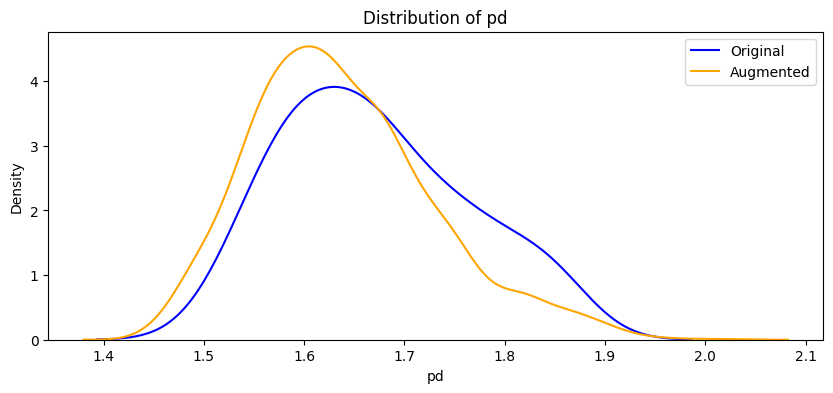

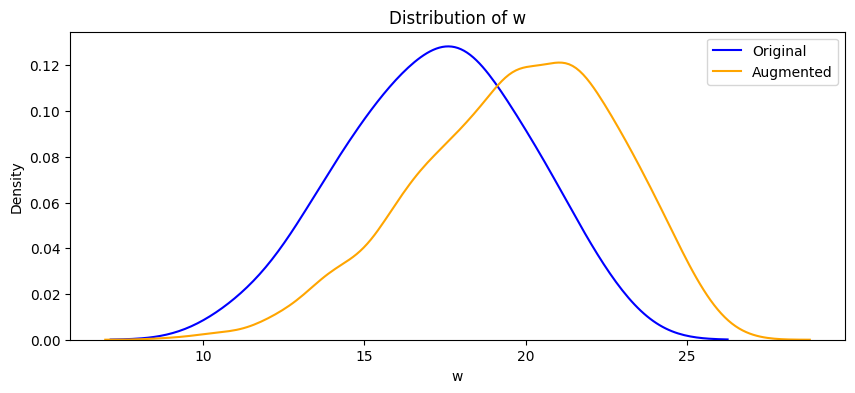

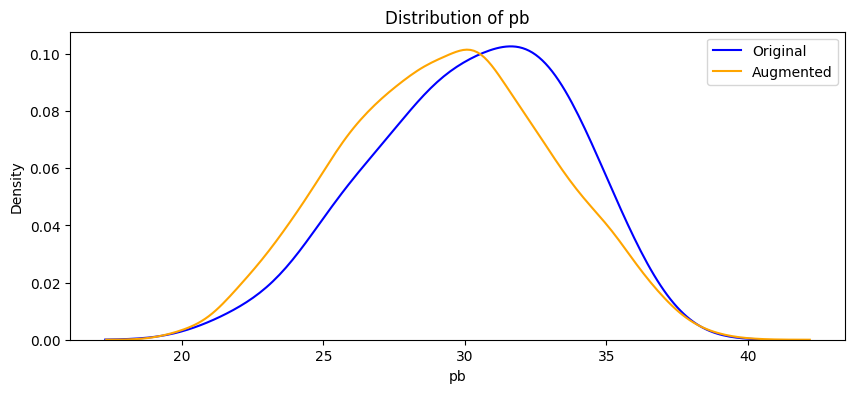

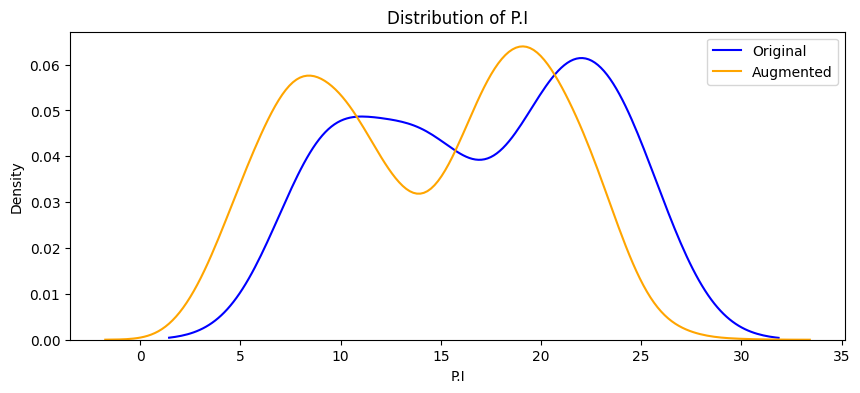

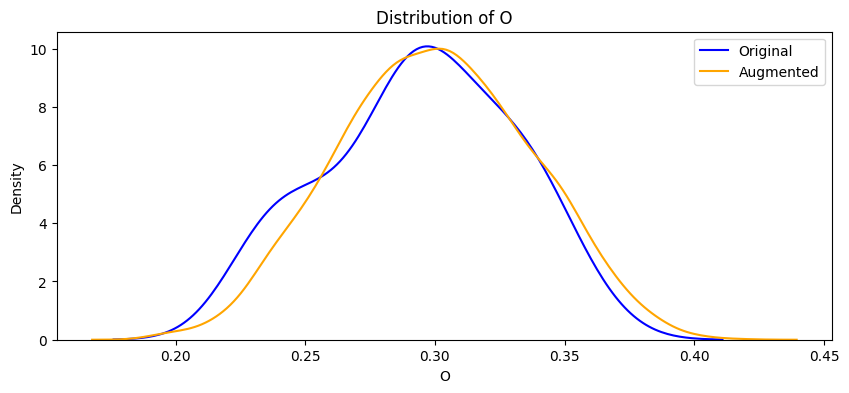

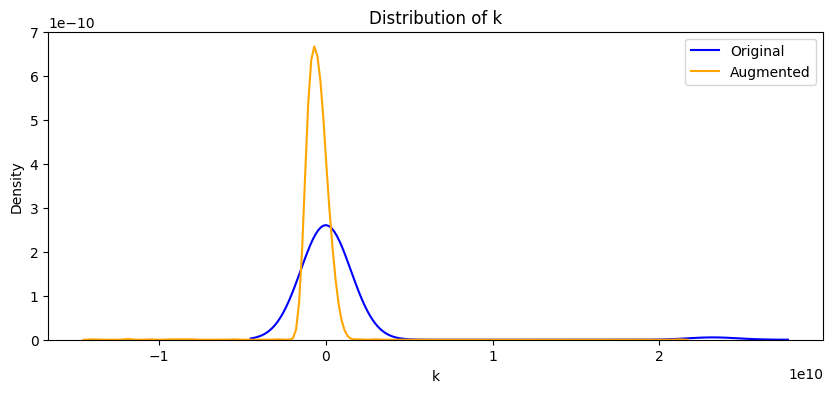

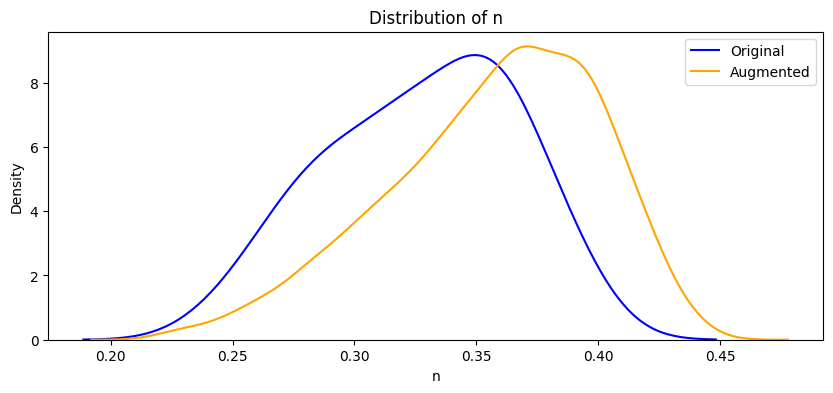

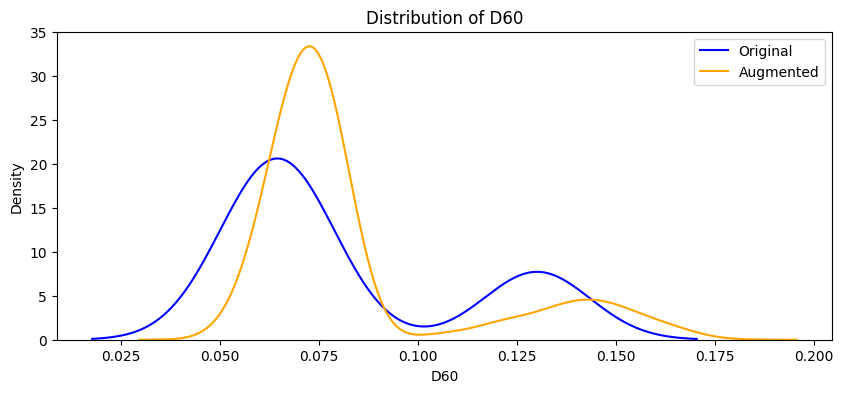

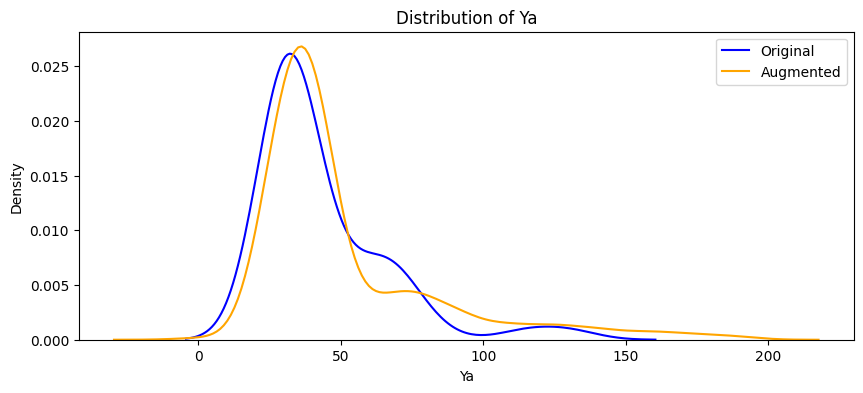

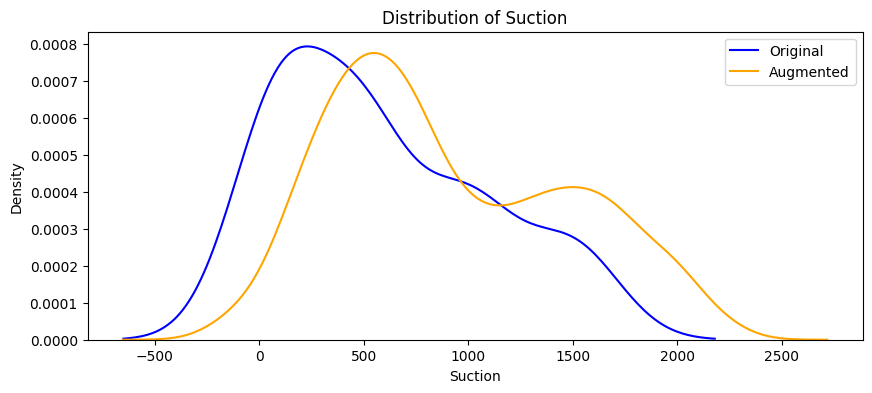

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load original and augmented datasets
original_data = pd.read_csv('abdullahi_karaye_new_dataset.csv')
augmented_data = pd.read_csv('augmented_dataset_ctgan.csv')  # Or SMOTE, etc.

# Compare feature distributions
for col in original_data.columns:
    plt.figure(figsize=(10, 4))
    sns.kdeplot(original_data[col], label='Original', color='blue')
    sns.kdeplot(augmented_data[col], label='Augmented', color='orange')
    plt.title(f'Distribution of {col}')
    plt.legend()
    plt.savefig(f'distribution_{col}.png')
    plt.show()
    # plt.close()

# Considerations
1. Domain Knowledge: Ensure synthetic data respects physical constraints (e.g., pd and pb are densities-related, so negative or unrealistic values are invalid).
2. Feature Correlations: Check that synthetic data preserves correlations between features (e.g., w and pb may be related).
3. Model Performance: Train a simple model (e.g., Random Forest) on the original vs. augmented dataset to verify improvement.
4. Suction Values: The target Suction has discrete values (e.g., 30, 100, 500, 1000, 1500). Ensure synthetic Suction values align with these or treat it as a classification problem.